In [41]:
# The usual suspects
import numpy as np
import matplotlib.pyplot as plt

# The EDIBLES bits that find files and load spectra
from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum

import sys
import os

gui_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

if gui_path not in sys.path:
 sys.path.insert(0, gui_path)

# Our project's own helpers (these live in the same folder as this notebook)
from flux_wave_find import wave_flux_data
from co_adding_flux import coadd_spectra
from main_run import get_species_data, astrovoigtfit_run
from main import master_function

# Make the plots a bit less ugly
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All imports happy. Onward.')

All imports happy. Onward.


In [42]:
star_name = 'HD 170740'
target_wave = 7698.965         # rest wavelength of the K_7699 line
wrange = [7697.0, 7700.0]       # window around the line for loading data

# Show every species the code already knows about
all_species = get_species_data('species.txt')
print('Species I know about:')
for name, info in all_species.items():
    print(f"  {name:20s} line={info['line']}  wrange={info['wrange']}")

Species I know about:
  K_4044               line=4044.142  wrange=[4043.0, 4045.0]
  K_7699               line=7698.965  wrange=[7697.0, 7700.0]
  12CH+_4032           line=4232.548  wrange=[4231.5, 4233.5]
  13CH+_4032           line=4232.548  wrange=[4231.5, 4233.5]
  7Li_6707             line=6707.761  wrange=[6707.1, 6708.2]
  6Li_6707             line=6707.761  wrange=[6707.1, 6708.2]
  Na_D_5892            line=5889.951  wrange=[5889.0, 5897.0]
  85Rb_7800            line=7800.250  wrange=[7798.0, 7800.9]
  87Rb_7800            line=7800.250  wrange=[7798.0, 7800.9]


In [43]:
oracle = EdiblesOracle()
files = oracle.getFilteredObsList([star_name], Wave=target_wave, MergedOnly=False)

# Turn it into a plain list so we can index it like normal humans
if hasattr(files, 'tolist'):
    files = files.tolist()

print(f'Found {len(files)} files covering {target_wave} A for {star_name}:\n')
for i, f in enumerate(files):
    print(f'  [{i}]  {f}')

***Common Objects***
['HD 170740']
**Filtered File List**
16687    orders/HD170740_2017-07-05T02:27:42_860nm_redl...
16861    orders/HD170740_2016-06-13T07:24:14_860nm_redl...
16874    combined/HD170740_2014-09-15T02:50:39_860nm_re...
17062    orders/HD170740_2014-09-15T02:50:39_860nm_redl...
17158    combined/HD170740_2017-07-05T02:27:42_860nm_re...
17172    orders/HD170740_2014-09-16T03:15:06_860nm_redl...
17200    combined/HD170740_2015-06-26T02:05:07_860nm_re...
17203    combined/HD170740_2016-06-13T07:24:14_860nm_re...
17260    orders/HD170740_2015-06-26T02:05:07_860nm_redl...
17309    combined/HD170740_2014-09-16T03:15:06_860nm_re...
Name: Filename, dtype: str
10
Found 10 files covering 7698.965 A for HD 170740:

  [0]  orders/HD170740_2017-07-05T02:27:42_860nm_redl_O13.fits
  [1]  orders/HD170740_2016-06-13T07:24:14_860nm_redl_O13.fits
  [2]  combined/HD170740_2014-09-15T02:50:39_860nm_redl.fits
  [3]  orders/HD170740_2014-09-15T02:50:39_860nm_redl_O13.fits
  [4]  combined/HD170

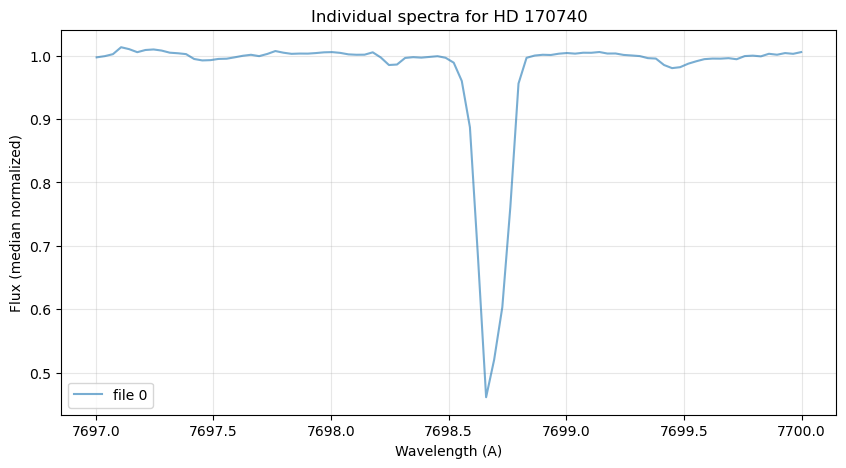

In [44]:
# Code for fitting just one spectrum
selected_index = 0

# Pull each spectrum from disk (just the wavelength window, median normalized)
wave_list = []
flux_list = []

# for i in [selected_index]:
#    fname = files[i]
w, f = wave_flux_data(star_name=star_name, wave=target_wave, wrange=wrange, file_name=r"orders/HD170740_2017-07-05T02:27:42_860nm_redl_O13.fits")
#    if w is None or len(w) == 0:
#        print(f'Skipping file {i}: no data in range')
#        continue
#    wave_list.append(w)
#    flux_list.append(f)
#    print(f'Loaded file {i}: {len(w)} points')

# Quick look so you can spot weirdos
plt.figure()
# for i, (w, f) in enumerate(zip(wave_list, flux_list)):
plt.plot(w, f, alpha=0.6, label=f'file {selected_index}')
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux (median normalized)')
plt.title(f'Individual spectra for {star_name}')
plt.legend()
plt.show()

In [45]:
sigma_per_spectrum = 0.002   # noise estimate per individual spectrum

# wave_coadd, flux_coadd, sigma_coadd = coadd_spectra(
#    wave_list, flux_list, sigma_list=sigma_per_spectrum)

w, f = wave_flux_data(star_name=star_name, wave=target_wave,
 wrange=wrange, file_name=r"orders/HD170740_2017-07-05T02:27:42_860nm_redl_O13.fits")
if w is None or len(w) == 0:
 print(f'No data in range for file {selected_index}')
else:
 print(f'Loaded file {selected_index}: {len(w)} points')

Loaded file 0: 88 points


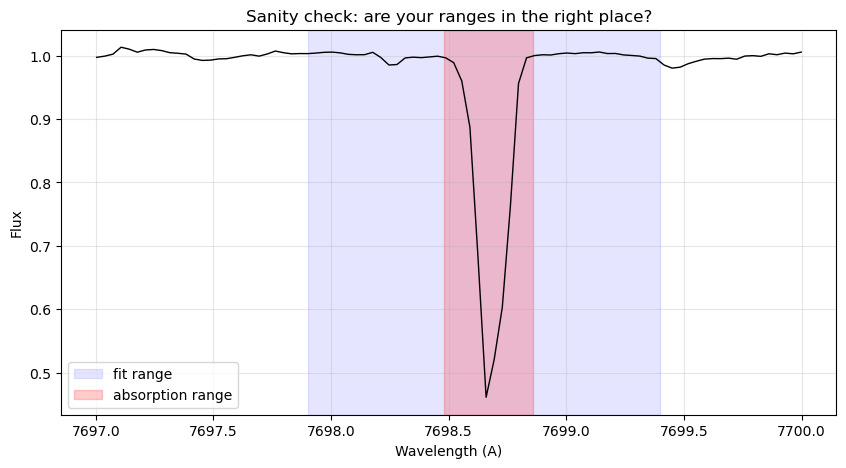

After cropping to fit range: 44 points


In [46]:
fit_range = (7697.9, 7699.4)
absorption_range = (7698.48, 7698.86)

plt.figure()
plt.plot(w, f, color='black', lw=1)
plt.axvspan(*fit_range, color='blue', alpha=0.1, label='fit range')
plt.axvspan(*absorption_range, color='red', alpha=0.2, label='absorption range')
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux')
plt.title('Sanity check: are your ranges in the right place?')
plt.legend()
plt.show()

# Crop the data to the fit range so we hand only the relevant chunk to the fitter
mask = (w >= fit_range[0]) & (w <= fit_range[1])
wave_fit = w[mask]
flux_fit = f[mask]
print(f'After cropping to fit range: {len(wave_fit)} points')

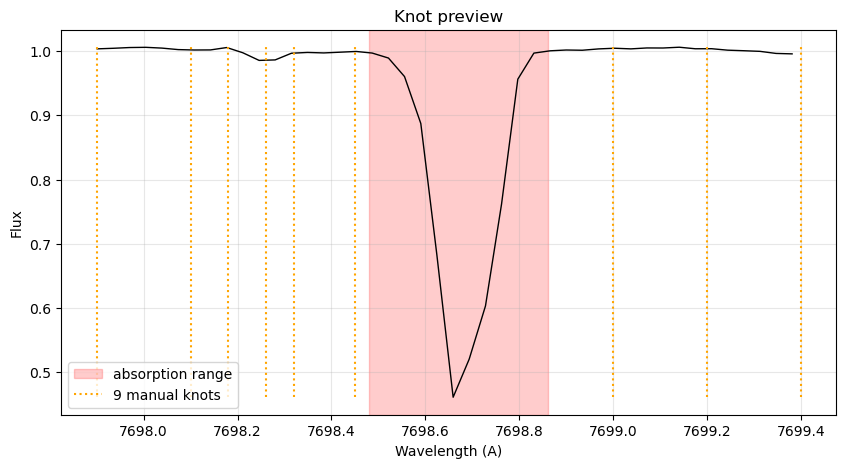

In [50]:
# Flavor A: auto, equidistant knots, just say how many
n_knots = 0
# knots_x_array = None

# Flavor B: manual, you say exactly where every knot goes
# Uncomment the next line to use manual mode (it overrides n_knots)
knots_x_array = [7697.9, 7698.1, 7698.18, 7698.26, 7698.32, 7698.45, 7699, 7699.2, 7699.4]  

spline_order = 1   # 1 linear, 2 quadratic, 3 cubic

# Preview where the knots would land
if knots_x_array is None:
    preview_knots = np.linspace(fit_range[0], fit_range[1], n_knots)
    inside_abs = (preview_knots >= absorption_range[0]) & (preview_knots <= absorption_range[1])
    preview_knots = preview_knots[~inside_abs]
    preview_knots = np.sort(np.unique(np.append(
        preview_knots, [absorption_range[0] - 0.05, absorption_range[1] + 0.05])))
    knot_label = f'{len(preview_knots)} auto knots (fitter may tweak)'
else:
    preview_knots = np.asarray(knots_x_array)
    knot_label = f'{len(preview_knots)} manual knots'

plt.figure()
plt.plot(wave_fit, flux_fit, color='black', lw=1)
plt.axvspan(*absorption_range, color='red', alpha=0.2, label='absorption range')
plt.vlines(preview_knots, flux_fit.min(), flux_fit.max(),
           colors='orange', linestyles=':', label=knot_label)
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux')
plt.title('Knot preview')
plt.legend()
plt.show()

In [141]:
molecules = ['K_7699'] #this should match with the first column of species.txt

species_params = {
    0: {
        'b':     [2, 2.5],
        'N':     [1e12, 5e11],
        'v_rad': [-5, -4],
    } #,   # uncomment if you have  second species
    # 1: {
    #     'b':     [2.0, 2.0],
    #     'N':     [1e12, 1e12],
    #     'v_rad': [5,5],
    # }
}

 

print(f"You're fitting {len(molecules)} species with these components:")
for i, mol in enumerate(molecules):
    p = species_params[i]
    print(f"  {mol}: {len(p['b'])} component(s)")
    print(f"    b     = {p['b']}")
    print(f"    N     = {p['N']}")
    print(f"    v_rad = {p['v_rad']}")


You're fitting 1 species with these components:
  K_7699: 2 component(s)
    b     = [2, 2.5]
    N     = [1000000000000.0, 500000000000.0]
    v_rad = [-5, -4]


In [142]:
fit_std_dev = 0.004 # standard dev of the co-added spectra 
# this is a very important parameter... ideally you should find 
# this by taking a wavelength region from the spectra where the continuum
# is pretty flatt with almost no absorption and fitting it 
# with a line and find the stardard dev of the data points 

fitresult, normalized_flux, continuum, residual_std = astrovoigtfit_run(
    wave_fit, flux_fit, molecules, species_params,
    absorption_range, n_knots=n_knots, knots_x_array=knots_x_array,
    species_file='species.txt', spline_order=spline_order,
    std_dev=fit_std_dev,
)

print(f'\nFit success:        {fitresult.success}')
print(f'Chi square:         {fitresult.chisqr:.4f}')
print(f'Reduced chi square: {fitresult.redchi:.4f}')
print(f'Std of residuals:   {residual_std:.5f}')

Species: K_7699, Lambda: [7698.965], f: [0.3331], Gamma: [37400000.0]
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([2. , 2.5]), 'N_1st': array([1.e+12, 5.e+11]), 'v_rad_1st': array([-5., -4.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([2. , 2.5]), 'N_1st': array([1.e+12, 5.e+11]), 'v_rad_1st': array([-5., -4.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([2. , 2.5]), 'N_1st': array([1.e+12, 5.e+11]), 'v_rad_1st': array([-5., -4.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([2. , 2.5]), 'N_1st': array([1.e+12, 5.e+11]), 'v_rad_1st': array([-5., -4.])}
master_kwargs {'lambda_1st': array([7698.965]), 'f_1st': array([0.3331]), 'gamma_1st': array([37400000.]), 'b_1st': array([2.0

In [143]:
params = fitresult.params

print(f'Star: {star_name}')
print('=' * 40)
for i, mol in enumerate(molecules):
    print(f'\nSpecies {i+1}: {mol}')
    comp_idx = 0
    while f'b_{i}_{comp_idx}' in params:
        b = params[f'b_{i}_{comp_idx}']
        N = params[f'N_{i}_{comp_idx}']
        v = params[f'v_rad_{i}_{comp_idx}']
        print(f'  Component {comp_idx+1}:')
        for p, label in [(b, 'b    '), (N, 'N    '), (v, 'v_rad')]:
            if p.stderr is None:
                print(f'    {label}: {p.value:.4g}  (fixed or tied)')
            else:
                pct = abs(p.stderr / p.value) * 100 if p.value != 0 else 0
                print(f'    {label}: {p.value:.4g} +/- {p.stderr:.4g}  ({pct:.2f}%)')
        comp_idx += 1

print(f'\nChi square:         {fitresult.chisqr:.4f}')
print(f'Reduced chi square: {fitresult.redchi:.4f}')

Star: HD 170740

Species 1: K_7699
  Component 1:
    b    : 0.9436 +/- 0.03199  (3.39%)
    N    : 4.716e+11 +/- 2.31e+10  (4.90%)
    v_rad: -5.975 +/- 0.02843  (0.48%)
  Component 2:
    b    : 0.7567 +/- 0.03977  (5.26%)
    N    : 2.304e+11 +/- 1.58e+10  (6.86%)
    v_rad: -4.527 +/- 0.04389  (0.97%)

Chi square:         125.1507
Reduced chi square: 3.2934


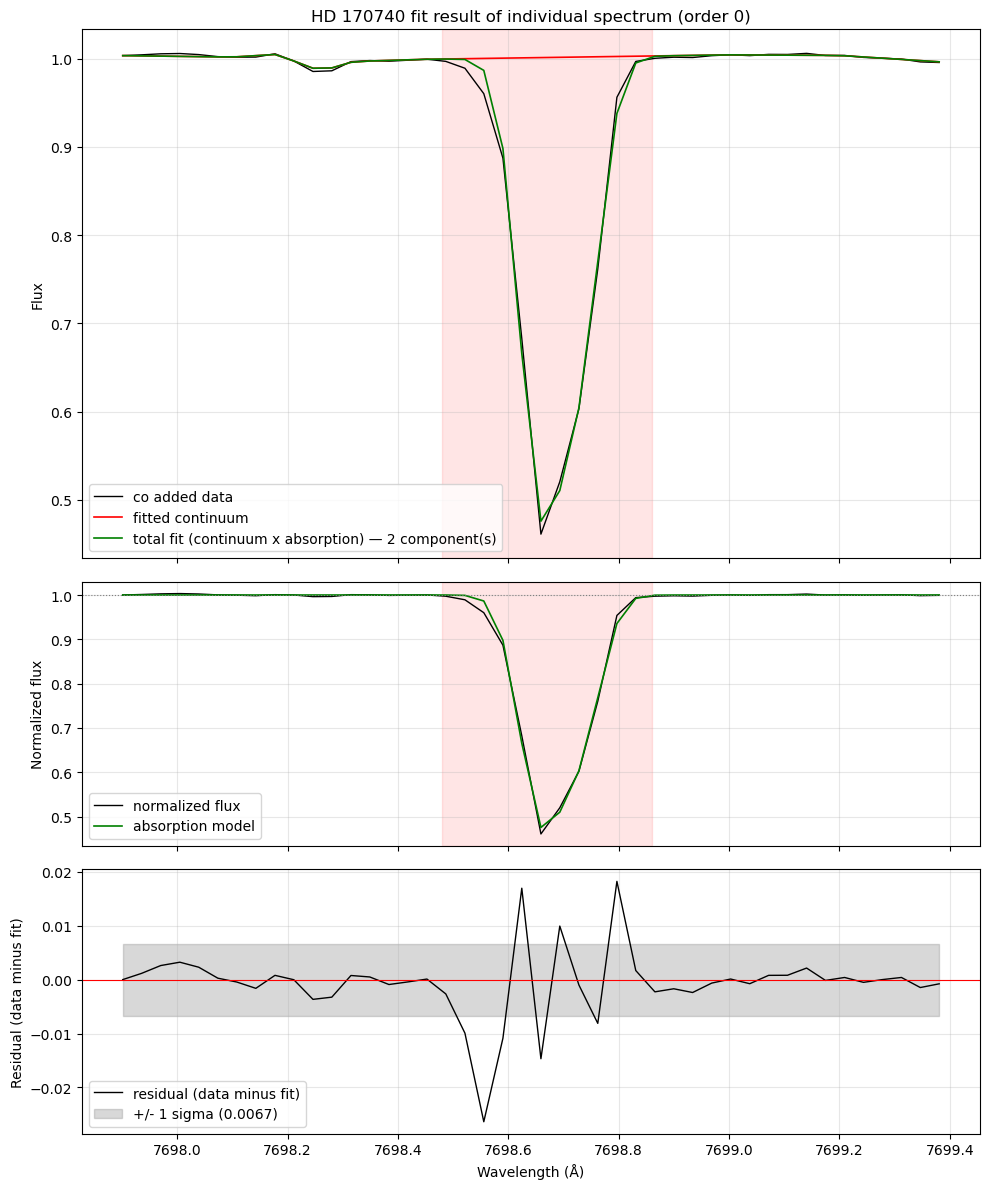

In [144]:
# Top: data + continuum + total fit. Bottom: normalized flux + absorption model.
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})

for i, mol in enumerate(molecules):
    p = species_params[i]
ax_top = axes[0]
ax_top.plot(wave_fit, flux_fit, color='black', lw=1, label='co added data')
ax_top.plot(wave_fit, continuum, color='red', lw=1.2, label='fitted continuum')
ax_top.plot(wave_fit, fitresult.best_fit, color='green', lw=1.2,
            label=f'total fit (continuum x absorption) — {len(p["b"])} component(s)')
ax_top.axvspan(*absorption_range, color='red', alpha=0.1)
ax_top.set_ylabel('Flux')
ax_top.set_title(f'{star_name} fit result of individual spectrum (order 0)')
ax_top.legend(loc='best')

ax_bot = axes[1]
ax_bot.plot(wave_fit, normalized_flux, color='black', lw=1, label='normalized flux')
ax_bot.plot(wave_fit, fitresult.best_fit / continuum, color='green', lw=1.2,
            label='absorption model')
ax_bot.axhline(1.0, color='gray', lw=0.8, linestyle=':')
ax_bot.axvspan(*absorption_range, color='red', alpha=0.1)
ax_bot.set_ylabel('Normalized flux')
ax_bot.legend()

ax_bot = axes[2]
ax_bot.plot(wave_fit, flux_fit - fitresult.best_fit, color='black', lw=1, label='residual (data minus fit)')
ax_bot.axhline(0, color='red', lw=0.8)
ax_bot.fill_between(wave_fit, -residual_std, residual_std, color='gray', alpha=0.3,
                 label=f'+/- 1 sigma ({residual_std:.4f})')
ax_bot.set_xlabel('Wavelength (Å)')
ax_bot.set_ylabel('Residual (data minus fit)')
ax_bot.legend(loc='lower left')


plt.tight_layout()
plt.savefig(r"C:\Users\User\Downloads\PYTHON PROJECTS\edibles\edibles\projects\GUI\KI_fits_self\results\plots\HD_170740_order0.png")
plt.show()

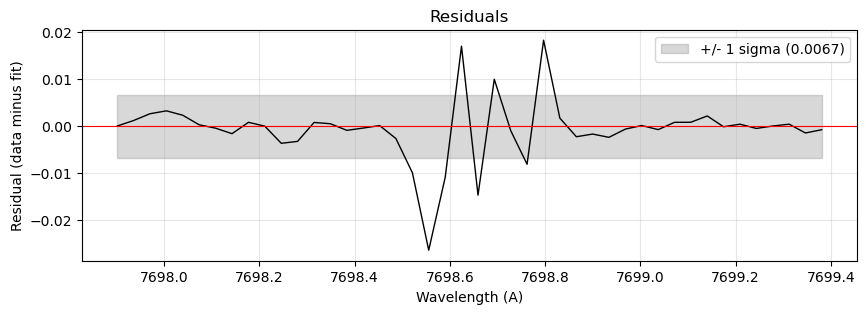

In [145]:
# Residuals: data minus total fit. Should look like noise centered on zero.
plt.figure(figsize=(10, 3))
plt.plot(wave_fit, flux_fit - fitresult.best_fit, color='black', lw=1)
plt.axhline(0, color='red', lw=0.8)
plt.fill_between(wave_fit, -residual_std, residual_std, color='gray', alpha=0.3,
                 label=f'+/- 1 sigma ({residual_std:.4f})')
plt.xlabel('Wavelength (A)')
plt.ylabel('Residual (data minus fit)')
plt.title('Residuals')
plt.legend()
plt.show()

In [146]:
fitresult.fit_report()
with open(r"C:\Users\User\Downloads\PYTHON PROJECTS\edibles\edibles\projects\GUI\KI_fits_self\results\HD 170740_order0_params.txt", 'w') as f:
 f.write(fitresult.fit_report())